
# Analytica Kepler — Exoplanetas com IA (Starter Notebook) 

**Time:** Analytica Kepler  
**Hackathon:** NASA Space Apps 2025 — *Um mundo distante: caçando exoplanetas com IA*  
**Linguagem:** Python (Jupyter Notebook)  
**Objetivo:** Baixar dados abertos, visualizar FITS do **NEOSSat** (CSA), montar uma curva de luz simplificada e, em paralelo, baixar tabelas rotuladas **KOI/TOI** (NASA Exoplanet Archive) para um baseline de classificação **com feature de missão**.

---

## Roteiro
1. **Setup** — instalar dependências e importar libs.
2. **NEOSSat** — listar e baixar alguns **FITS** (amostra).
3. **Inspeção** — abrir FITS, ver cabeçalho e imagem.
4. **Curva de luz simplificada** — soma em abertura (toy).
5. **Tabelas rotuladas (NASA)** — baixar **KOI** e **TOI** via TAP.
6. **Baseline ML** — classificar `koi_disposition` (RandomForest) **incluindo `mission`**.
7. **Próximos passos** — ideias para web e melhorias.



### 1) Setup — instalar dependências


In [7]:

# %%capture
%pip -q install numpy pandas matplotlib requests beautifulsoup4 astropy scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



### 2) Imports e configuração inicial


In [8]:

from pathlib import Path
import os, io, gzip, re, sys, math, textwrap
import requests
from bs4 import BeautifulSoup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

# Pastas locais
DATA_DIR = Path('data/neossat_fits').resolve()
MODELS_DIR = Path('models').resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# URLs NEOSSat (CSA Open Data)
NEOSSAT_BASE = "https://data.asc-csa.gc.ca/users/OpenData_DonneesOuvertes/pub/NEOSSAT/ASTRO/"
DEFAULT_YEAR = "2025"

print(f"Dados locais: {DATA_DIR}")
print(f"Modelos: {MODELS_DIR}")
print(f"NEOSSat pasta base: {NEOSSAT_BASE}{DEFAULT_YEAR}/")


Dados locais: C:\Users\gus\Documents\UFRJ\UFRJ ANALYTICA\NASA\kepler\data\neossat_fits
Modelos: C:\Users\gus\Documents\UFRJ\UFRJ ANALYTICA\NASA\kepler\models
NEOSSat pasta base: https://data.asc-csa.gc.ca/users/OpenData_DonneesOuvertes/pub/NEOSSAT/ASTRO/2025/



### 3) NEOSSat — listar e baixar alguns FITS


In [9]:

def list_fits_from_year(year='2025', limit=5):
    year_url = f"{NEOSSAT_BASE}{year}/"
    r = requests.get(year_url, timeout=60)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, 'html.parser')
    subdirs = [a.get('href') for a in soup.select('a') if a.get('href', '').endswith('/') and a.get('href') not in ('../',)]
    found = []
    for sd in subdirs:
        sub_url = year_url + sd
        try:
            rr = requests.get(sub_url, timeout=60)
            rr.raise_for_status()
            ss = BeautifulSoup(rr.text, 'html.parser')
            links = [a.get('href') for a in ss.select('a') if a.get('href')]
            for href in links:
                if href.lower().endswith(('.fits', '.fits.gz')):
                    found.append(sub_url + href)
                    if len(found) >= limit:
                        return found
        except Exception as e:
            print(f"Aviso: não foi possível varrer {sub_url} -> {e}")
            continue
    return found

def download_url(url, out_dir=DATA_DIR):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = url.split('/')[-1]
    dest = out_dir / fname
    if dest.exists():
        return dest
    print(f"Baixando: {url}")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    with open(dest, 'wb') as f:
        f.write(r.content)
    return dest

YEAR = DEFAULT_YEAR
N_SAMPLE = 5

fits_urls = list_fits_from_year(YEAR, limit=N_SAMPLE)
print(f"Encontrados {len(fits_urls)} arquivos (amostra):\n- " + "\n- ".join(fits_urls))

downloaded = [download_url(u) for u in fits_urls]
downloaded


Aviso: não foi possível varrer https://data.asc-csa.gc.ca/users/OpenData_DonneesOuvertes/pub/NEOSSAT/ASTRO/2025//users/OpenData_DonneesOuvertes/pub/NEOSSAT/ASTRO/ -> 404 Client Error: Not Found for url: https://data.asc-csa.gc.ca/users/OpenData_DonneesOuvertes/pub/NEOSSAT/ASTRO/2025//users/OpenData_DonneesOuvertes/pub/NEOSSAT/ASTRO/
Encontrados 5 arquivos (amostra):
- https://data.asc-csa.gc.ca/users/OpenData_DonneesOuvertes/pub/NEOSSAT/ASTRO/2025/001/NEOS_SCI_2025001000009.fits.gz
- https://data.asc-csa.gc.ca/users/OpenData_DonneesOuvertes/pub/NEOSSAT/ASTRO/2025/001/NEOS_SCI_2025001000009_cor.fits.gz
- https://data.asc-csa.gc.ca/users/OpenData_DonneesOuvertes/pub/NEOSSAT/ASTRO/2025/001/NEOS_SCI_2025001000009_cord.fits.gz
- https://data.asc-csa.gc.ca/users/OpenData_DonneesOuvertes/pub/NEOSSAT/ASTRO/2025/001/NEOS_SCI_2025001000045.fits.gz
- https://data.asc-csa.gc.ca/users/OpenData_DonneesOuvertes/pub/NEOSSAT/ASTRO/2025/001/NEOS_SCI_2025001000045_cor.fits.gz


[WindowsPath('C:/Users/gus/Documents/UFRJ/UFRJ ANALYTICA/NASA/kepler/data/neossat_fits/NEOS_SCI_2025001000009.fits.gz'),
 WindowsPath('C:/Users/gus/Documents/UFRJ/UFRJ ANALYTICA/NASA/kepler/data/neossat_fits/NEOS_SCI_2025001000009_cor.fits.gz'),
 WindowsPath('C:/Users/gus/Documents/UFRJ/UFRJ ANALYTICA/NASA/kepler/data/neossat_fits/NEOS_SCI_2025001000009_cord.fits.gz'),
 WindowsPath('C:/Users/gus/Documents/UFRJ/UFRJ ANALYTICA/NASA/kepler/data/neossat_fits/NEOS_SCI_2025001000045.fits.gz'),
 WindowsPath('C:/Users/gus/Documents/UFRJ/UFRJ ANALYTICA/NASA/kepler/data/neossat_fits/NEOS_SCI_2025001000045_cor.fits.gz')]


### 4) Inspeção de um FITS do NEOSSat


Filename: C:\Users\gus\Documents\UFRJ\UFRJ ANALYTICA\NASA\kepler\data\neossat_fits\NEOS_SCI_2025001000009.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     700   (856, 512)   int16 (rescales to uint16)   
  1  RawVolt       1 BinTableHDU     17   24R x 2C   [12A, 1I]   
  2  ACS_History    1 BinTableHDU     47   152R x 10C   [1E, 19A, 10A, 1E, 1E, 1E, 1E, 1E, 1E, 1E]   
  3  Image_RDList    1 BinTableHDU     18   7R x 3C   [1I, 1I, 1I]   
  4  CCD_History    1 BinTableHDU     26   30R x 4C   [1E, 1I, 1B, 1B]   
  5  RawTlm        1 BinTableHDU     17   15R x 2C   [12A, 1I]   

Cabeçalho principal (subset):

    SIMPLE: True
    BITPIX: 16
     NAXIS: 2
    NAXIS1: 856
    NAXIS2: 512
    EXTEND: True
    BSCALE: 1
     BZERO: 32768
     IMAGE: 
   BIASSEC: [1:64,1:512]
   TRIMSEC: [345:856,1:512]
   DATASEC: [345:856,1:512]
    CCDSEC: [281:792,261:772]
  CORNER1X: -64
  CORNER1Y: 260
  CORNER2X: 791
  CORNER2Y: 771
     OPAMP: RI

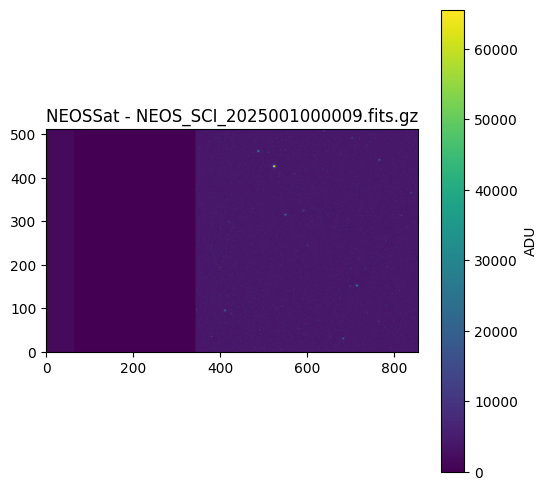

In [10]:

first = downloaded[0] if downloaded else None
assert first is not None, "Nenhum FITS baixado. Volte à célula anterior."

hdul = fits.open(first)
hdul.info()

hdr = hdul[0].header
img = hdul[0].data
print("\nCabeçalho principal (subset):\n")
for k in list(hdr.keys())[:30]:
    try:
        print(f"{k:>10}: {hdr[k]}")
    except Exception:
        pass

plt.figure(figsize=(6,6))
plt.imshow(img, origin='lower')
plt.title(f"NEOSSat - {first.name}")
plt.colorbar(label='ADU')
plt.show()

hdul.close()



### 5) Curva de luz *toy* (aperture sum)


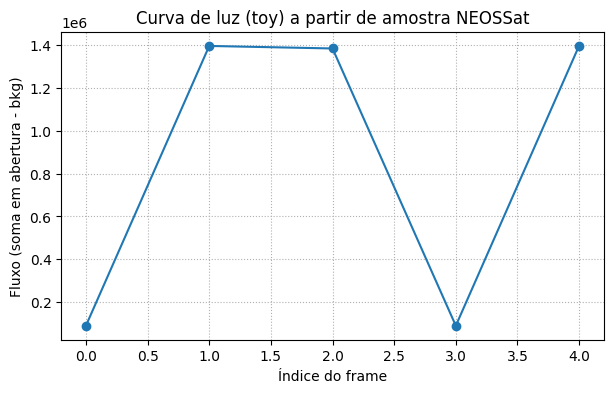

,frame,flux
0,NEOS_SCI_2025001000009.fits.gz,90338.0
1,NEOS_SCI_2025001000009_cor.fits.gz,1395785.0
2,NEOS_SCI_2025001000009_cord.fits.gz,1383983.0
3,NEOS_SCI_2025001000045.fits.gz,90216.0
4,NEOS_SCI_2025001000045_cor.fits.gz,1396812.0


In [11]:

from math import hypot
import numpy as np

def aperture_sum(image, cx, cy, r=5):
    h, w = image.shape
    r2 = r*r
    s = 0.0
    for y in range(max(0, cy-r), min(h, cy+r+1)):
        for x in range(max(0, cx-r), min(w, cx+r+1)):
            if (x-cx)*(x-cx)+(y-cy)*(y-cy) <= r2:
                s += image[y, x]
    return s

fluxes, frames = [], []
for f in downloaded:
    with fits.open(f) as hd:
        img = hd[0].data.astype(float)
        bkg = np.nanmedian(img)
        img2 = img - bkg
        yx = np.unravel_index(np.nanargmax(img2), img2.shape)
        cy, cx = int(yx[0]), int(yx[1])
        flux = aperture_sum(img2, cx, cy, r=5)
        fluxes.append(flux)
        frames.append(f.name)

plt.figure(figsize=(7,4))
plt.plot(range(len(fluxes)), fluxes, marker='o')
plt.xlabel('Índice do frame')
plt.ylabel('Fluxo (soma em abertura - bkg)')
plt.title('Curva de luz (toy) a partir de amostra NEOSSat')
plt.grid(True, linestyle=':')
plt.show()

pd.DataFrame({'frame': frames, 'flux': fluxes})



### 6) Tabelas rotuladas (NASA Exoplanet Archive) — KOI e TOI via TAP


In [12]:

from urllib.parse import quote_plus
import pandas as pd

TAP_BASE = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

koi_cols = [
    "kepid","kepoi_name","koi_disposition",
    "koi_period","koi_duration","koi_depth","koi_prad","koi_impact","koi_srad","koi_smass"
]
koi_query = f"select+{','.join(koi_cols)}+from+cumulative"
koi_url = f"{TAP_BASE}?query={koi_query}&format=csv"
print('KOI URL:', koi_url)
koi_df = pd.read_csv(koi_url)
koi_df.head()


KOI URL: https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+kepid,kepoi_name,koi_disposition,koi_period,koi_duration,koi_depth,koi_prad,koi_impact,koi_srad,koi_smass+from+cumulative&format=csv


,kepid,kepoi_name,koi_disposition,koi_period,koi_duration,koi_depth,koi_prad,koi_impact,koi_srad,koi_smass
0,10797460,K00752.01,CONFIRMED,9.488036,2.95750,615.8,2.26,0.146,0.927,0.919
1,10797460,K00752.02,CONFIRMED,54.418383,4.50700,874.8,2.83,0.586,0.927,0.919
2,10811496,K00753.01,CANDIDATE,19.899140,1.78220,10829.0,14.60,0.969,0.868,0.961
3,10848459,K00754.01,FALSE POSITIVE,1.736952,2.40641,8079.2,33.46,1.276,0.791,0.836
4,10854555,K00755.01,CONFIRMED,2.525592,1.65450,603.3,2.75,0.701,1.046,1.095


In [15]:
rename_map = {
    "tid": "tic_id",
    "pl_orbper": "orbital_period",
    "pl_trandurh": "transit_duration",
    "pl_trandep": "transit_depth",
    "pl_rade": "planet_radius",
    "st_rad": "stellar_radius",
    "st_teff": "stellar_teff"
}
toi_std = toi_df.rename(columns=rename_map)
toi_std.head()


,toi,tic_id,tfopwg_disp,orbital_period,transit_depth,transit_duration,planet_radius,stellar_radius,stellar_teff
0,1049.01,16288184,KP,2.180528,16340.135320,2.969175,16.808853,1.27146,6599.0
1,105.01,144065872,KP,2.184667,11708.022855,2.865280,13.702853,1.23824,5630.0
2,1050.01,66818296,KP,3.735484,17030.000000,4.142000,21.231500,1.57000,6650.0
3,1051.01,259863352,FA,21.701669,211.656733,8.267642,2.375149,1.56486,5625.0
4,1052.01,317060587,CP,9.139804,358.415780,3.091294,3.062985,1.58000,5958.2


In [19]:
from urllib.parse import quote_plus
import pandas as pd

TAP_BASE = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

q = """
select
  toi,
  tid as tic_id,
  tfopwg_disp,
  pl_orbper  as orbital_period,
  pl_trandep as transit_depth,
  pl_trandurh as transit_duration,
  pl_rade    as planet_radius,
  st_rad     as stellar_radius,
  st_teff    as stellar_teff
from toi
"""
toi_url = f"{TAP_BASE}?query={quote_plus(' '.join(q.split()))}&format=csv"
print("TOI URL:", toi_url)

toi_df = pd.read_csv(toi_url)
toi_df.head()


TOI URL: https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+toi%2C+tid+as+tic_id%2C+tfopwg_disp%2C+pl_orbper+as+orbital_period%2C+pl_trandep+as+transit_depth%2C+pl_trandurh+as+transit_duration%2C+pl_rade+as+planet_radius%2C+st_rad+as+stellar_radius%2C+st_teff+as+stellar_teff+from+toi&format=csv


,toi,tic_id,tfopwg_disp,orbital_period,transit_depth,transit_duration,planet_radius,stellar_radius,stellar_teff
0,1049.01,16288184,KP,2.180528,16340.135320,2.969175,16.808853,1.27146,6599.0
1,105.01,144065872,KP,2.184667,11708.022855,2.865280,13.702853,1.23824,5630.0
2,1050.01,66818296,KP,3.735484,17030.000000,4.142000,21.231500,1.57000,6650.0
3,1051.01,259863352,FA,21.701669,211.656733,8.267642,2.375149,1.56486,5625.0
4,1052.01,317060587,CP,9.139804,358.415780,3.091294,3.062985,1.58000,5958.2



### 7) Baseline ML — classificar `koi_disposition` (inclui feature `mission`)


In [20]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# --- Adição de "missão" (KOI = Kepler; TOI = TESS) ---
koi_df["mission"] = "Kepler"
try:
    toi_df["mission"] = "TESS"
except NameError:
    pass

# Seleciona features numéricas simples e alvo
use_cols = ["koi_period","koi_duration","koi_depth","koi_prad","koi_impact","koi_srad","koi_smass"]
df = koi_df.dropna(subset=use_cols + ["koi_disposition"]).copy()

# One-hot da missão (aqui será "Kepler" neste subset, mas já deixa pronto para juntar TESS no futuro)
mission_ohe = pd.get_dummies(df["mission"], prefix="mission")
X_num = df[use_cols].values
X = np.hstack([X_num, mission_ohe.values])
feature_names = use_cols + list(mission_ohe.columns)

y = df["koi_disposition"].astype(str).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print("Acurácia:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# Importâncias de features (inclui missão)
imp = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
imp


Acurácia: 0.7283789656671013
                precision    recall  f1-score   support

     CANDIDATE       0.48      0.41      0.44       469
     CONFIRMED       0.73      0.77      0.75       686
FALSE POSITIVE       0.81      0.83      0.82      1146

      accuracy                           0.73      2301
     macro avg       0.67      0.67      0.67      2301
  weighted avg       0.72      0.73      0.72      2301



koi_period        0.207052
koi_prad          0.185871
koi_depth         0.158442
koi_impact        0.130272
koi_duration      0.129668
koi_srad          0.097888
koi_smass         0.090807
mission_Kepler    0.000000
dtype: float64


### 8) Salvar o baseline treinado


In [ ]:

import pickle, os
model_path = Path('models/koi_rf_with_mission.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(clf, f)
model_path



### 9) Próximos passos (checklist)
- Melhorar fotometria (photutils), alinhar frames, *flags* de qualidade.
- Combinar KOI+TOI num único dataset com `mission` e avaliar domínio cruzado.
- Integrar geração de *features* do NEOSSat (cabeçalho + estatísticas) e inferir.
- Streamlit/Deploy (Railway) com upload de CSV/LC e gráficos.
- Relatório de calibração e PR-AUC por missão.

> Notebook atualizado em: 2025-10-04 17:35:06
